# Challenge: Missing Values

| [![leader-badge]][leader-url] |
|:-:|

[leader-badge]: https://img.shields.io/badge/leaderboard-grey?style=for-the-badge&logoColor=white

[leader-url]: https://github.com/climet-eu/compression-lab-notebooks/issues/47

You are challenged to find a compressor that produces the highest compression ratio when compressing the provided satellite observation example dataset with an absolute error bound. The dataset contains missing values. The compressor must preserve the missing values and must not violate the error bound.

This product includes software produced by UChicago Argonne, LLC under Contract No. DE-AC02-06CH11357 with the Department of Energy.

In [1]:
import sys

sys.path.insert(0, "../..")

In [2]:
import h5netcdf
import numpy as np
import xarray as xr
from upath import UPath

In [3]:
# URL of S3 bucket
BASE_URL = "https://object-store.os-api.cci1.ecmwf.int/esiwacebucket"

data = UPath(BASE_URL)

In [4]:
import earthkit.plots

import importlib.util
import tempfile
from pathlib import Path
from urllib.request import urlopen

REFERENCE_UTILS_URL = "https://raw.githubusercontent.com/igonzal-bsc/compression-lab-notebooks/a00d8025c1f6a64d77a126ad31966adce5d957d8/utils.py"
reference_utils_path = Path(tempfile.gettempdir()) / "compression_lab_notebooks_utils.py"
if not reference_utils_path.exists():
    reference_utils_path.write_bytes(urlopen(REFERENCE_UTILS_URL).read())
reference_utils_spec = importlib.util.spec_from_file_location("reference_utils", reference_utils_path)
reference_utils = importlib.util.module_from_spec(reference_utils_spec)
reference_utils_spec.loader.exec_module(reference_utils)

open_remote_dataset = reference_utils.open_remote_dataset
quickplot = reference_utils.quickplot

## Challenge Configuration (do not edit)

In [5]:
# Load the data
ds = open_remote_dataset(
    data / "HOAPS" / "HOAPS_2020-08_6-hourly.nc",
    engine="h5netcdf",
    decode_timedelta=True,
)
da = ds["wvpa"].sel(time=slice("2020-08-01", "2020-08-07"))

In [6]:
eb_abs_check = 1  # kg m-2

## Compressor Configuration (edit here)

In [7]:
eb_abs = 1  # kg m-2

In [8]:
from brace_compressor import BraceCodec

codec = BraceCodec(shape=da.shape, error_bound=eb_abs, missing_value="nan")


In [9]:
print(codec.get_config())

{'id': 'brace-wvpa', 'shape': [28, 320, 720], 'error_bound': 1.0, 'missing_value': 'nan', 'dtype': 'float32', 'outer_compress': True}


## Challenge Evaluation (do not edit)

In [10]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc, out=np.empty(da.shape, dtype=da.dtype)))
cr=da.nbytes / np.array(da_enc).nbytes
print(f"Compression ratio: {cr:.2f}")

Compression ratio: 61.16


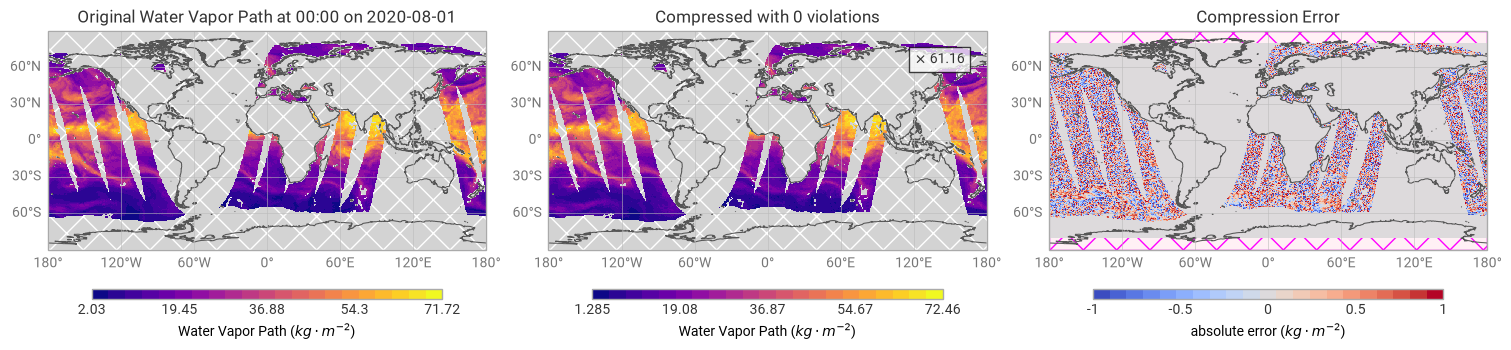

In [11]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    figsize=(15, 4),
    rows=1,
    columns=3,
)

# violation if
# (a) the absolute error bound is exceeded
# (b) missing NaN values are not preserved
violations = np.mean(
    xr.where(
        np.isnan(da),
        ~np.isnan(da_dec),
        ~(np.abs(da_dec - da) <= eb_abs_check),
    )
)
violations = (
    0
    if violations == 0
    else np.format_float_positional(100 * violations, precision=1, min_digits=1) + "%"
)
if violations == "0.0%":
    violations = "<0.05%"

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec,
    fig.add_map(0, 1),
    title=f"Compressed with {violations} violations",
    cr=da.nbytes / np.array(da_enc).nbytes,
)
quickplot(
    xr.where(np.isnan(da) & np.isnan(da_dec), 0, da_dec - da).assign_attrs(
        long_name="absolute error", units=da.units
    ),
    fig.add_map(0, 2),
    error=True,
    vrange=(-eb_abs_check, eb_abs_check),
    title="Compression Error",
)

fig.show()